# Machine Learning for Multibody System Dynamics

## **Session 1-2:** Example of linear oscillator surrogate model

> Details: This file uses previously created data. It is a short bridge example only.

Peter Manzl and Grzegorz Orzechowski

## Import packages and set seeds

In [1]:
import time
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# manually setting a seed 
np.random.seed(0)
torch.manual_seed(0)

## Load Data from file

Data contains the following fields:
- `inputsTraining`
- `targetsTraining`
- `inputsTest`
- `targetsTest`

We’ll read them into pyTorch tensors, using `float32` and inspect shapes.

- **input**: $\boldsymbol{x} = [x_0, \dot{x}_0, F_0, \ldots,  F_{n-1}]^T$
- **output**: $\boldsymbol{y} = [x_1, \ldots, x_n]^T$  with $x_i = x(t=i\cdot h)$; $h = 0.5/64$
- note that the force is scaled by 1/2000 to normalize the input vector.

In [2]:
myData = np.load('../data/LinearOscillatorT256-64s64randomExcitationmkd0_test.npy', allow_pickle=True).item()

inputsTraining = torch.tensor(myData['inputsTraining'], dtype=torch.float32)
targetsTraining = torch.tensor(myData['targetsTraining'], dtype=torch.float32)
inputsTest= torch.tensor(myData['inputsTest'], dtype=torch.float32)
targetsTest = torch.tensor(myData['targetsTest'], dtype=torch.float32) 

nTraining =  myData['inputsTraining'].shape[0]
nTest = myData['inputsTest'].shape[0]

print('dataset size training: {} and validation: {}.'.format(nTraining, nTest))
print('input: {}, output: {}'.format(np.array(inputsTraining[0].shape), np.array(targetsTraining[0].shape)))

dataset size training: 256 and validation: 64.
input: [66  1], output: [64  1]


## Time Vector for Plotting

We reconstruct the time‐axis `t_out` as in the original example:
- The sampling interval $h = \frac{0.5}{64}$.
- There are 64 output time‐steps.

In [3]:
h = 0.5/64
t_out = np.linspace(h, h*64, 64)

## Define Neural Network Surrogate

We use a single linear layer (no bias) to map inputs → outputs.  

$$\boldsymbol{y} = \boldsymbol{W} \boldsymbol{x}$$

Note: Here we explicitly use a linear layer as our neural network surrogate.

In [4]:
myNeuralNetwork = nn.Sequential(
                nn.Flatten(), 
                # flatten reduces the dimensionality to a single dimension. 
                # This can also be applied to the dataset instead of the neural network.  
                nn.Linear(np.prod(myData['inputShape']), np.prod(myData['outputShape']), bias=False),
                # here more layers can be added like e.g.:
                # nn.Sigmoid, nn.ReLU, nn.Tanh, etc. 
                # note that between activation functions in general linear layers should be added. 
                # Important: Take care that the size of layers fit together. Depending on how layers
                # are arranged, different "neural network architectures" are configured. 
                nn.Unflatten(dim=1, unflattened_size= myData['outputShape']), 
                # restore the shape we want to have as output
                # instead of Flatten/unflatten, we could also do this operation on the data instead of the network. 
                )
# the Sequential object holds the neural network layers. 

### Visualize linear Layer

In the untrained state this is "just" noise and depends only on the initialization procedure.
Because we have only one linear layer, we can visualize the weight matrix directly as a heatmap.

**Info:**  [initialization methods of pytorch](https://pytorch.org/docs/stable/nn.init.html)


In [5]:
# Linear layers are per default initialized 
outTest_init = myNeuralNetwork(inputsTest).detach().numpy() # this will not fit well yet as it is not trained. 

Text(0, 0.5, 'output index')

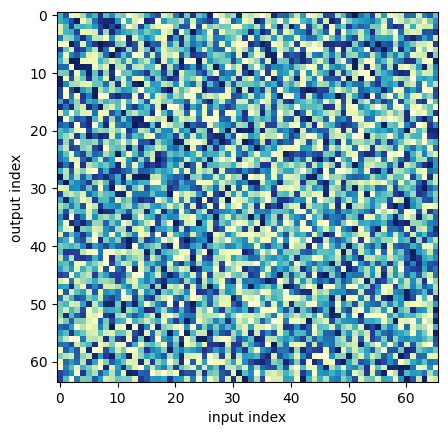

In [6]:
plt.figure()
w_initialized = myNeuralNetwork[1].weight.detach()
plt.imshow(w_initialized, cmap="YlGnBu", interpolation='nearest')
plt.xlabel('input index')
plt.ylabel('output index')

## Hyperparameters

In deep learning Hyperparameters are _configuration variables_ for training and are required to reproduce results.  
Hyperparameters are e.g.: 
* Size of training / validation / test dataset. 
* neural network architecture and settings: number and size of layers, activation function,  

- **Optimizer:** ADAM with learning rate $5 \times 10^{-2}$

      Note that such a learning rate is very high for most examples.
    
- **Epochs:** 1200
    
- **Batch size:** 256

In [7]:
loss_fn = nn.MSELoss() # loss function used for optimization
optimizer = torch.optim.Adam(myNeuralNetwork.parameters(), lr=5e-2) # Adam optimizer. lr: learning rate. 
# optimizer = torch.optim.SGD(myNeuralNetwork.parameters(), lr=0.01, momentum=0.9) # SVD optimizer
# In this example stochastic gradient decent (SGD) does not work well. 

# create dataset structure and dataloader
batchSize = 256
nEpoch = 1200

## Prepare DataLoaders

We transpose inputsTraining and targetsTraining so that each batch is (inputDim, batchSize) → (outputDim, batchSize).

- Training DataLoader shuffles each epoch.
    
- Validation DataLoader does not shuffle.

In [8]:
# the dataloader shuffles data and returns n=batchSize samples
dataset_training = TensorDataset(inputsTraining, targetsTraining)
dataloader_training = DataLoader(dataset_training, batch_size=batchSize, shuffle=True)
# Note: validation loss is computed directly on inputsTest/targetsTest inside the training loop

## Training Loop

In [9]:
#%% train our network
loss_epoch, lossEpoch, lossValidation = [], [], []
t1 = time.time()
for j in range(nEpoch):     
    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    running_loss = 0
    optimizer.zero_grad()
    for i, data in enumerate(dataloader_training):
        # Every data instance obtained from the dataloader is an input + target pair
        inputs, target = data
        # zero gradients for every batch
        optimizer.zero_grad()
    
        # Make predictions for this batch
        outputs = myNeuralNetwork(inputs)
    
        # Compute the loss and its gradients
        loss = loss_fn(outputs, target)
        loss.backward() # backpropagation
    
        # Adjust weights
        optimizer.step()
    
        running_loss += loss.item()
    loss_epoch += [running_loss / (i+1)] # divide loss by number of items

    # strictly speaking when evaluated while training it is called "validation" set, otherwise "test" set. 
    # validation: 
    if j % 10 == 0: 
        lossEpoch += [j]
        lossValidation += [loss_fn(myNeuralNetwork(inputsTest), targetsTest).detach().numpy()]
lossValidation = np.array(lossValidation)
print('training took {:.2f} seconds'.format(time.time() - t1))
print('final training loss : {:.3e}'.format(loss_epoch[-1]))
print('final test loss     : {:.3e}'.format(loss_fn(myNeuralNetwork(inputsTest), targetsTest).item()))

training took 0.94 seconds
final training loss : 1.079e-14
final test loss     : 2.014e-14


## Combined Plot of Training and Validation Losses

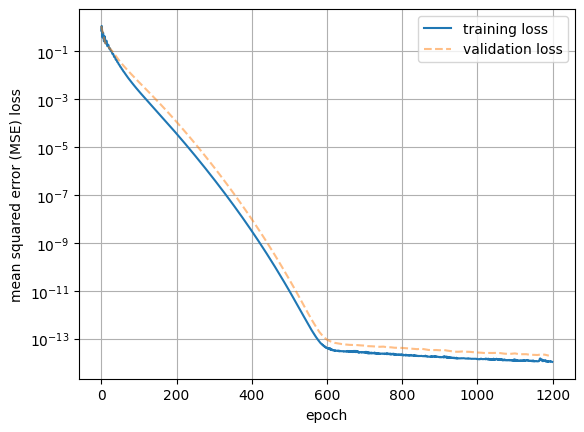

In [10]:
#%% plot training
plt.figure()
plt.semilogy(loss_epoch, label='training loss')
plt.semilogy(lossEpoch, np.array(lossValidation), '--', label='validation loss', alpha=0.5)
plt.grid()
plt.xlabel('epoch')
plt.ylabel('mean squared error (MSE) loss')
plt.legend()

#### Note:
* The validation set can be used to identify overfitting: training loss might still decrease while validation loss increases. 
* Nonlinear activation functions (e.g. ReLu) would decrease accuracy in this case
* This accuracy can only be expected in the linear case.
* Due to non-deterministic nature of methods applied in deep learning, the minimum might not be always reached.
* When restarting training on the trained network the loss increases, thus accuracy declines.  


In this example a linear spring-damper system is trained with a single linear layer, thus (numerically) perfect fit is possible. While values vary strongly by application, in _real world_ examples loss might be closer to the $10^{-4}...10^{-8}$ range. 


## Visualize Weight Matrix — the system's Green's function

The trained weight matrix $W \in \mathbb{R}^{64 \times 66}$ isn't just a learned bag of numbers. For this **linear** oscillator it has a meaning every MBD reader will recognise:

| Column | What it represents |
|--------|--------------------|
| $0$ | response trajectory due to a unit initial displacement $x_0 = 1$ |
| $1$ | response trajectory due to a unit initial velocity $\dot x_0 = 1$ |
| $2 + j$ | response trajectory due to a unit force pulse on $[t_j,\, t_{j+1})$ |

The last block of 64 columns is the **discrete [Green's function](https://en.wikipedia.org/wiki/Green%27s_function)** of the system: the network has learned the discrete equivalent of the [Duhamel integral](https://en.wikipedia.org/wiki/Duhamel%27s_integral). Look for the **[Toeplitz structure](https://en.wikipedia.org/wiki/Toeplitz_matrix)** in the heatmap below: each of columns 2–65 is the previous one shifted down by one row (causality + time-invariance).

Text(0, 0.5, 'output index')

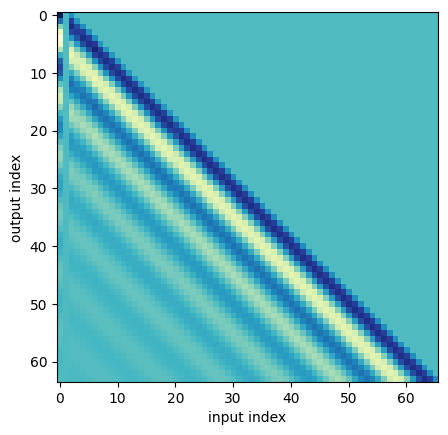

In [11]:
#%% 
plt.figure()
w_trained = myNeuralNetwork[1].weight.detach()
plt.imshow(w_trained, cmap="YlGnBu", interpolation='nearest')
plt.xlabel('input index')
plt.ylabel('output index')

### Where does the Toeplitz structure come from?

Three short steps — continuous solution, discretisation, matrix form.

#### 1. The continuous Duhamel formula

For the linear oscillator $m\ddot x + d\dot x + k x = F(t)$ with $x(0) = x_0$, $\dot x(0) = v_0$:

$$x(t) \;=\; \underbrace{\phi_x(t)\,x_0 \,+\, \phi_v(t)\,v_0}_{\text{free response}} \;+\; \underbrace{\int_0^t h(t - \tau)\,F(\tau)\,d\tau}_{\text{Duhamel integral}}$$

- $h(t)$ is the system's **impulse response** (its Green's function).
- $\phi_x(t),\,\phi_v(t)$ are the free responses to a unit position / velocity at $t = 0$.

Everything is *linear* in $x_0$, $\dot x_0$, and $F(\cdot)$. That linearity is the whole reason a matrix–vector product can fit it.

#### 2. Discretise — sample $x$, hold $F$ piecewise constant

Sample $x$ at $t_i = i\,h$ and treat $F(\tau) = F_j$ on the interval $[t_j,\, t_{j+1})$. The integral becomes a sum:

$$x_i \;=\; \phi_x(t_i)\,x_0 \;+\; \phi_v(t_i)\,v_0 \;+\; \sum_{j=0}^{i-1}\, g_{i-j}\, F_j$$

with

$$g_k \;:=\; \int_{(k-1)h}^{k h} h(s)\,ds \qquad (k \ge 1)$$

$g_k$ is the **pulse response at lag $k$** — the displacement at time $k h$ caused by a unit force held over one interval. It depends only on the *difference* between observation time and pulse time.

#### 3. Stack the equation into a matrix

Writing $\mathbf{y} = W\mathbf{x}$ with $\mathbf{x} = [x_0,\,\dot x_0,\,F_0,\,F_1,\,\dots,\,F_{63}]^\top$:

$$W \;=\; \begin{bmatrix}
\phi_x(t_1)    & \phi_v(t_1)    & g_1    & 0      & 0      & \cdots & 0   \\
\phi_x(t_2)    & \phi_v(t_2)    & g_2    & g_1    & 0      & \cdots & 0   \\
\phi_x(t_3)    & \phi_v(t_3)    & g_3    & g_2    & g_1    & \cdots & 0   \\
\vdots         & \vdots         & \vdots & \vdots & \vdots & \ddots & \vdots \\
\phi_x(t_{64}) & \phi_v(t_{64}) & g_{64} & g_{63} & g_{62} & \cdots & g_1
\end{bmatrix}$$

#### What to see in the heatmap

- **Causality.** Entries above the leading diagonal of the forced block are exactly zero — the system can't respond to a force pulse before it happens.
- **Time-invariance (Toeplitz).** $W[i,\,2+j] = g_{i-j}$ depends only on the *difference* $i - j$. Every diagonal of the forced block carries one value, and each column is the previous one shifted *down by one row*. That repeating-diagonals pattern is what "Toeplitz" means.

#### The punchline

When the heatmap shows this Toeplitz pattern in the right-hand block, the network has not "approximated" anything — it has **parameterised the exact LTI solution**:

- Columns 0–1: the homogeneous solutions $\phi_x,\,\phi_v$.
- Columns 2–65: the discrete convolution kernel $\{g_k\}$, repeated and shifted.

Multiplying $W \mathbf{x}$ is literally a *discrete convolution* of the force sequence with the impulse response, plus the two free-response terms. Same object, two languages.

#### Why a single linear layer suffices

For a linear ODE the solution is a **linear combination** of inputs:

$$\boldsymbol{y} \;=\; W_{x_0}\,x_0 \;+\; W_{\dot x_0}\,\dot x_0 \;+\; \sum_{j=0}^{n-1} W_{F_j}\,F_j$$

Each $W_{\bullet}$ is a vector — the system's response to a unit of that input. Stack them as columns of a matrix and you get exactly $\boldsymbol{y} = W \boldsymbol{x}$, the forward pass of a single linear layer.

The forward pass through the trained network is therefore identical to applying superposition by hand. There is nothing else to learn — a linear layer is *the* right architecture for this system, not merely *a* good one.

Add a cubic term in $x$ (the Duffing oscillator in [Session 2-1](../Session-2-SupervisedLearning/2-1_Duffing_Equation.ipynb)) and superposition breaks — that's where nonlinear activations and depth start to earn their keep.

## Interactive Burst
Question: Why is this linear case still interpretable from the weight matrix, while the later Duffing surrogates are much harder to interpret directly?

## Plot Three Weight Columns — Free and Impulse Responses

Three columns are worth a close look:
- **Column 0:** free response to $x_0 = 1$ — a damped cosine starting at 1.
- **Column 1:** free response to $\dot x_0 = 1$ — a damped sine starting at 0.
- **Column 2:** response to a unit force pulse on $[0,\,h)$ — the system's **impulse response**, identical (up to discretisation) to what you would derive analytically from $m\ddot x + d\dot x + k x = F$.

If training converged, all three should look like recognisable textbook curves.

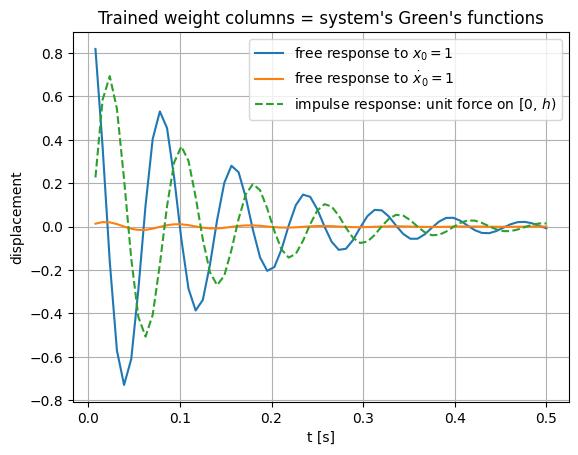

In [12]:
plt.figure()
plt.plot(t_out, w_trained[:, 0],       label=r'free response to $x_0 = 1$')
plt.plot(t_out, w_trained[:, 1],       label=r'free response to $\dot x_0 = 1$')
plt.plot(t_out, w_trained[:, 2], '--', label=r'impulse response: unit force on $[0,\,h)$')
plt.xlabel('t [s]')
plt.ylabel('displacement')
plt.title("Trained weight columns = system's Green's functions")
plt.legend()
plt.grid()

## Plot Predictions vs. True Signal (First Test Sample)

Compare the neural network’s predicted time-series against the true target for the first test sample.

relative test error  ||y_pred - y_true||_2 / ||y_true||_2  =  0.000%


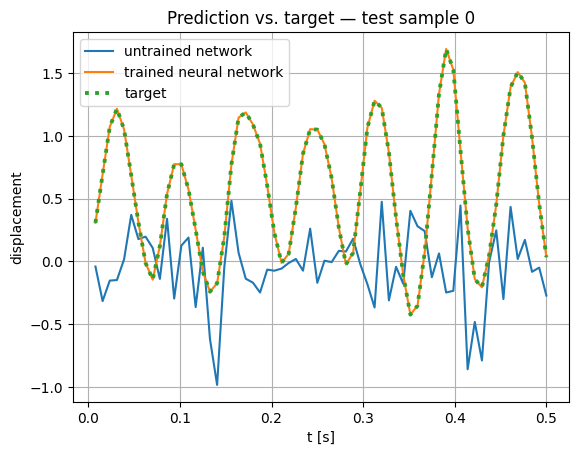

In [13]:
plt.figure()
outTest = myNeuralNetwork(inputsTest).detach().numpy()
plt.plot(t_out, outTest_init[0], label='untrained network') 
plt.plot(t_out, outTest[0], label='trained neural network', linewidth=1.5)
plt.plot(t_out, targetsTest[0], ':', label='target', linewidth=2.75)
plt.xlabel('t [s]')
plt.ylabel('displacement')
plt.title('Prediction vs. target — test sample 0')
plt.legend()
plt.grid()

# Numeric anchor: relative L2 error across the whole test set
targets_np = targetsTest.detach().numpy()
rel_err = np.linalg.norm(outTest - targets_np) / np.linalg.norm(targets_np)
print(f'relative test error  ||y_pred - y_true||_2 / ||y_true||_2  =  {rel_err:.3%}')

### Note on extrapolation

Neural networks generally **work best for interpolation** in the trained range and often fail to extrapolate outside. As in this example only a linear layer is used, it might generalize better. 

## Final Notes

A *single linear layer with no bias* learned to predict the entire trajectory of a linear oscillator. The trained weight matrix is the system's **discrete Green's function** — the same object you would derive analytically from $m\ddot x + d\dot x + k x = F$ via Duhamel's integral.

This worked **because the system is linear**: superposition guarantees that a matrix–vector product is the exact functional form of the solution. No depth, no nonlinearity, no tricks were required.

### Try

- Increase the learning rate to $10^{-1}$ — does training still converge?
- Train for fewer epochs (e.g. 200) — what does the weight matrix look like compared to the converged result?
- Add a hidden layer with `nn.SiLU()` between two linear layers and train again. Is it better, worse, or the same? (Hint: you've added capacity the problem doesn't need.)

### What's next?

[Session 2-1](../Session-2-SupervisedLearning/2-1_Duffing_Equation.ipynb) adds a cubic restoring force $\alpha k\,x^3$. Superposition no longer holds, so a single linear layer cannot fit the response. That's the point where nonlinear activations and depth start to earn their keep.